# `np.gradient` vs. automatic differentiation for the WW input

This notebook compares, step by step, two ways of computing the coordinate-space WW input

$$\alpha_s F_{WW}(r,x)=\frac{C_F S_\perp}{2\pi^2}\,\mathcal{K}(r,x)\left[1-S_F(r,x)^{N_c/C_F}\right],$$

where

$$\Gamma(r,x)=-\log S_F(r,x),\qquad
\mathcal{K}(r,x)=\frac{\nabla_\perp^2\Gamma(r,x)}{\Gamma(r,x)},\qquad
\nabla_\perp^2\Gamma=\frac{\partial^2\Gamma}{\partial r^2}+\frac1r\frac{\partial\Gamma}{\partial r}.$$

- **Finite-difference version**: `tmd_gluon_ww_running.ww_alpha_s_f_r`, using `np.gradient` to differentiate twice on the $\ln r$ grid.
- **Automatic-differentiation version**: `dipole_function.ww_alpha_s_f_r_autograd`, using PyTorch autograd to take the second derivative w.r.t. $r$ directly.

Key identity (the two should agree): $\nabla_\perp^2\Gamma=\dfrac{1}{r^2}\dfrac{\partial^2\Gamma}{\partial(\ln r)^2}$.

## 1. Imports and parameters

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from dipole_function import (
    ww_kernel_r,
    ww_alpha_s_f_r_autograd,
    _color_factors,
    _second_argument,
)
from tmd_gluon_ww_running import ww_alpha_s_f_r, dipole_s_matrix

# Common parameters
X = 1.0e-3          # Bjorken x
X0_FOR_Y = 0.03     # Y = ln(x0/x)
S_PERP = 1.0
NC = 3.0
EPS = 1.0e-10

c_f, c_a = _color_factors(NC)
print(f'C_F = {c_f:.6f},  C_A = {c_a:.6f},  N_c/C_F = {c_a / c_f:.6f}')
print(f'Y = ln(x0/x) = {_second_argument(X, X0_FOR_Y):.6f}')

CUDA device architecture sm_120 is not supported by this PyTorch build; running on the CPU
C_F = 1.333333,  C_A = 3.000000,  N_c/C_F = 2.250000
Y = ln(x0/x) = 3.401197


/home/congyi/.conda/envs/torch/lib/python3.11/site-packages/torch/cuda/__init__.py:287: UserWarning: 
NVIDIA GeForce RTX 5080 with CUDA capability sm_120 is not compatible with the current PyTorch installation.
The current PyTorch install supports CUDA capabilities sm_50 sm_60 sm_70 sm_75 sm_80 sm_86 sm_37 sm_90.
If you want to use the NVIDIA GeForce RTX 5080 GPU with PyTorch, please check the instructions at https://pytorch.org/get-started/locally/

  warnings.warn(


In [2]:
# Log-uniform r grid (np.gradient needs an evenly spaced ln r)
R_MIN, R_MAX, N_R = 1.0e-3, 1.0e2, 512
r = np.geomspace(R_MIN, R_MAX, N_R)
log_r = np.log(r)
print(f'r grid: {N_R} points, r in [{r[0]:.1e}, {r[-1]:.1e}]')

r grid: 512 points, r in [1.0e-03, 1.0e+02]


## 2. Intermediate quantities: $\Gamma$ and $\nabla_\perp^2\Gamma$

First compute the Laplacian of $\Gamma$ with both methods and inspect the difference between finite differences and autograd directly.

In [3]:
# --- Finite differences (np.gradient) ---
s_f_num = dipole_s_matrix(r, X, x0_for_y=X0_FOR_Y, eps=EPS)
gamma_num = np.maximum(-np.log(s_f_num), EPS)
dG_num = np.gradient(gamma_num, log_r, edge_order=2)
d2G_num = np.gradient(dG_num, log_r, edge_order=2)
lap_num = d2G_num / r**2          # (1/r^2) d^2Gamma/d(ln r)^2

# --- Automatic differentiation (autograd) ---
K_ad, s_f_ad, gamma_ad, lap_ad = ww_kernel_r(
    r, X, x0_for_Y=X0_FOR_Y, eps=EPS, return_parts=True
)

print('S_F      max|diff| =', np.max(np.abs(s_f_num - s_f_ad)))
print('Gamma    max|diff| =', np.max(np.abs(gamma_num - gamma_ad)))
print('Laplacian max|diff| =', np.max(np.abs(lap_num - lap_ad)))

S_F      max|diff| = 2.9802322387695312e-08
Gamma    max|diff| = 4.867641152372926e-07
Laplacian max|diff| = 0.02092271546528468


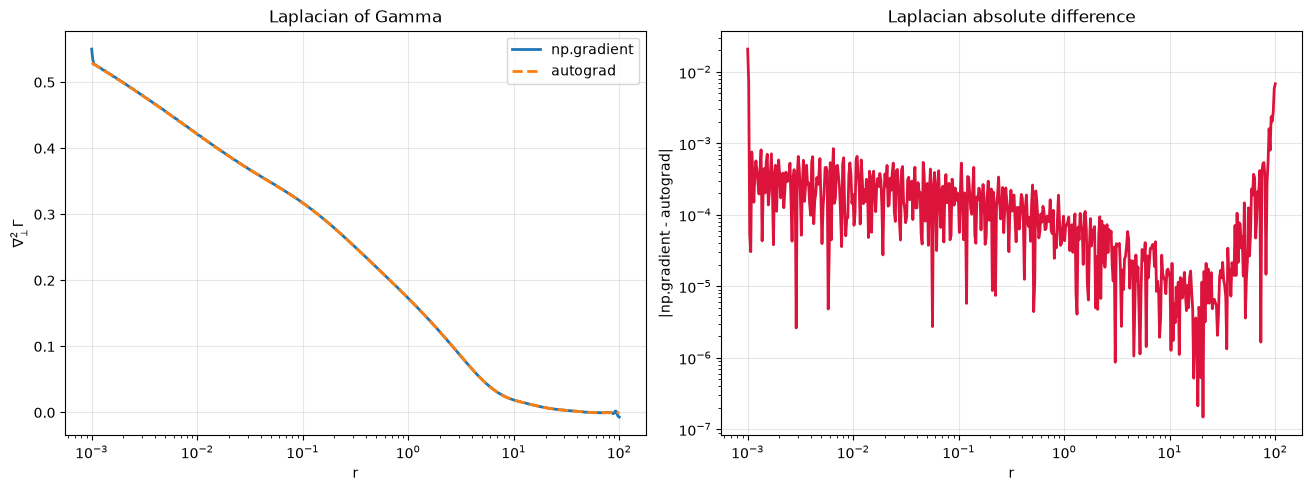

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8), constrained_layout=True)

axes[0].plot(r, lap_num, label='np.gradient', lw=2)
axes[0].plot(r, lap_ad, '--', label='autograd', lw=2)
axes[0].set_xscale('log')
axes[0].set_xlabel('r')
axes[0].set_ylabel(r'$\nabla_\perp^2 \Gamma$')
axes[0].set_title('Laplacian of Gamma')
axes[0].legend()
axes[0].grid(alpha=0.3)

abs_diff = np.abs(lap_num - lap_ad)
axes[1].plot(r, abs_diff, color='crimson', lw=2)
axes[1].set_xscale('log')
axes[1].set_yscale('log')
axes[1].set_xlabel('r')
axes[1].set_ylabel('|np.gradient - autograd|')
axes[1].set_title('Laplacian absolute difference')
axes[1].grid(alpha=0.3)
plt.show()

## 3. Full $\alpha_s F_{WW}$ comparison

In [5]:
ww_num = ww_alpha_s_f_r(r, X, S_perp=S_PERP, Nc=NC, x0_for_y=X0_FOR_Y, eps=EPS)
ww_ad = ww_alpha_s_f_r_autograd(r, X, S_perp=S_PERP, Nc=NC, x0_for_Y=X0_FOR_Y, eps=EPS)

abs_diff = np.abs(ww_num - ww_ad)
scale = np.maximum(np.abs(ww_num), np.abs(ww_ad))
rel_diff = np.where(scale > 0, abs_diff / scale, 0.0)

print('alpha_s F_WW  max|abs diff| =', np.max(abs_diff))
print('alpha_s F_WW  max|rel diff| =', np.max(rel_diff))

# The interior (away from the grid boundaries) usually agrees better
interior = slice(N_R // 10, -N_R // 10)
print('interior max|rel diff| =', np.max(rel_diff[interior]))

alpha_s F_WW  max|abs diff| = 0.01211732440083993
alpha_s F_WW  max|rel diff| = 1.9201620838260463
interior max|rel diff| = 0.010506319201925522


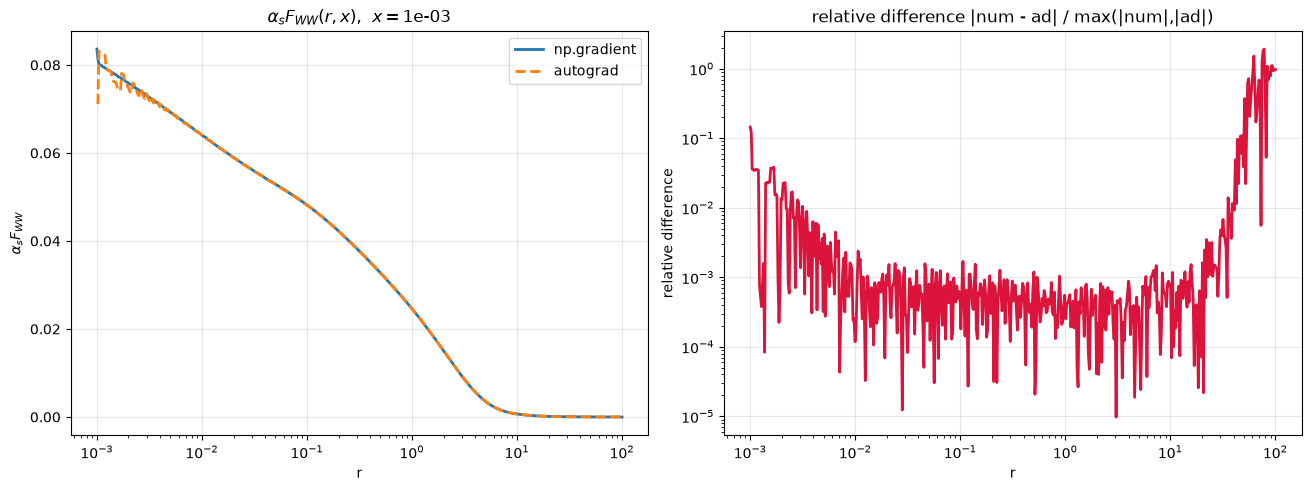

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8), constrained_layout=True)

axes[0].plot(r, ww_num, label='np.gradient', lw=2)
axes[0].plot(r, ww_ad, '--', label='autograd', lw=2)
axes[0].set_xscale('log')
axes[0].set_xlabel('r')
axes[0].set_ylabel(r'$\alpha_s F_{WW}$')
axes[0].set_title(r'$\alpha_s F_{WW}(r,x)$,  $x=$%.0e' % X)
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(r, rel_diff, color='crimson', lw=2)
axes[1].set_xscale('log')
axes[1].set_yscale('log')
axes[1].set_xlabel('r')
axes[1].set_ylabel('relative difference')
axes[1].set_title('relative difference |num - ad| / max(|num|,|ad|)')
axes[1].grid(alpha=0.3)
plt.show()

## 4. Effect of grid resolution on the finite-difference error

Automatic differentiation is grid-independent; the `np.gradient` error decreases as the grid is refined. Using autograd as the reference, we examine how the finite-difference result converges.

n=   64  interior max rel diff = 3.949e-02
n=  128  interior max rel diff = 1.441e-02
n=  256  interior max rel diff = 9.558e-03
n=  512  interior max rel diff = 1.051e-02
n= 1024  interior max rel diff = 3.090e-02
n= 2048  interior max rel diff = 2.015e-01


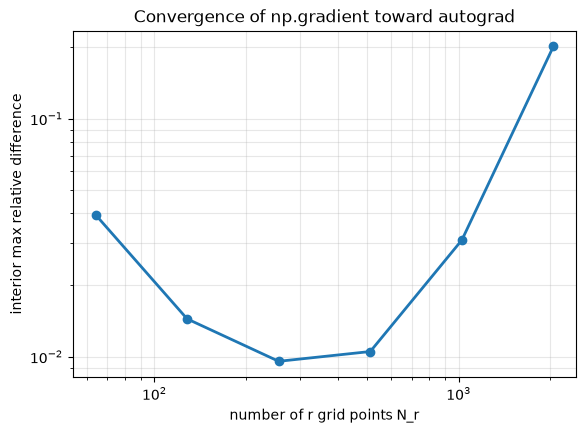

In [7]:
grid_sizes = [64, 128, 256, 512, 1024, 2048]
max_rel = []

for n in grid_sizes:
    rr = np.geomspace(R_MIN, R_MAX, n)
    num = ww_alpha_s_f_r(rr, X, S_perp=S_PERP, Nc=NC, x0_for_y=X0_FOR_Y, eps=EPS)
    ad = ww_alpha_s_f_r_autograd(rr, X, S_perp=S_PERP, Nc=NC, x0_for_Y=X0_FOR_Y, eps=EPS)
    sc = np.maximum(np.abs(num), np.abs(ad))
    rel = np.where(sc > 0, np.abs(num - ad) / sc, 0.0)
    inner = slice(n // 10, -n // 10)
    max_rel.append(np.max(rel[inner]))
    print(f'n={n:5d}  interior max rel diff = {max_rel[-1]:.3e}')

plt.figure(figsize=(6.5, 4.5))
plt.loglog(grid_sizes, max_rel, 'o-', lw=2)
plt.xlabel('number of r grid points N_r')
plt.ylabel('interior max relative difference')
plt.title('Convergence of np.gradient toward autograd')
plt.grid(alpha=0.3, which='both')
plt.show()

## 5. Summary

- The two methods agree closely in the **interior** of the grid, validating the correctness of the autograd implementation.
- The differences are concentrated at the **grid boundaries** and in the **high-curvature / small-$r$** region, which is the intrinsic truncation error of finite differences.
- The `np.gradient` error converges as the grid is refined (roughly $O(\Delta \ln r^2)$), whereas autograd is grid-independent and analytically smooth.
- Therefore, when a high-accuracy $\nabla_\perp^2\Gamma$ is needed (especially near boundaries or on sparse grids), `ww_alpha_s_f_r_autograd` is recommended.

## 6. float32 vs. float64: suppressing the small-$r$ oscillations

The small-$r$ oscillations of the autograd result are a float32 round-off artifact: the transverse Laplacian carries a factor $1/r^2$ (huge at small $r$), while $\Gamma=-\log S_F\to 0$ as $S_F\to 1$, so the twice-differentiated, then divided, quantity amplifies the $\sim 10^{-7}$ float32 noise.

`ww_alpha_s_f_r_autograd` now accepts `dtype=torch.float64`, which evaluates a cached double-precision copy of the model. Below we compare the two precisions on the same grid.

In [8]:
import torch

ww_ad32 = ww_alpha_s_f_r_autograd(
    r, X, S_perp=S_PERP, Nc=NC, x0_for_Y=X0_FOR_Y, eps=EPS, dtype=torch.float32
)
ww_ad64 = ww_alpha_s_f_r_autograd(
    r, X, S_perp=S_PERP, Nc=NC, x0_for_Y=X0_FOR_Y, eps=EPS, dtype=torch.float64
)

# Roughness metric: std of the discrete 2nd difference in the small-r region.
# A smooth curve gives a small value; oscillations give a large one.
small = r < 1.0e-1


def roughness(y):
    return float(np.std(np.diff(y[small], n=2)))


print('small-r roughness (float32):', roughness(ww_ad32))
print('small-r roughness (float64):', roughness(ww_ad64))
print('reduction factor:', roughness(ww_ad32) / max(roughness(ww_ad64), 1e-30))

small-r roughness (float32): 0.0013843791093677282
small-r roughness (float64): 4.595780118534703e-07
reduction factor: 3012.2831677358777


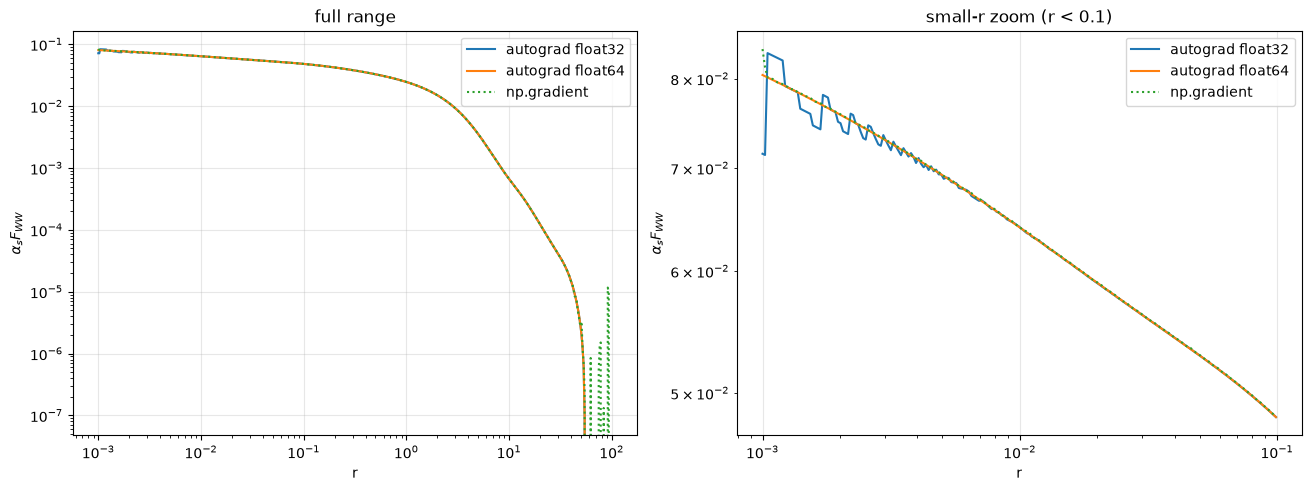

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8), constrained_layout=True)

axes[0].plot(r, ww_ad32, label='autograd float32', lw=1.5)
axes[0].plot(r, ww_ad64, label='autograd float64', lw=1.5)
axes[0].plot(r, ww_num, ':', label='np.gradient', lw=1.5)
axes[0].set_xscale('log')
axes[0].set_yscale('log')
axes[0].set_xlabel('r')
axes[0].set_ylabel(r'$\alpha_s F_{WW}$')
axes[0].set_title('full range')
axes[0].legend()
axes[0].grid(alpha=0.3)

m = r < 1.0e-1
axes[1].plot(r[m], ww_ad32[m], label='autograd float32', lw=1.5)
axes[1].plot(r[m], ww_ad64[m], label='autograd float64', lw=1.5)
axes[1].plot(r[m], ww_num[m], ':', label='np.gradient', lw=1.5)
axes[1].set_xscale('log')
axes[1].set_yscale('log')
axes[1].set_xlabel('r')
axes[1].set_ylabel(r'$\alpha_s F_{WW}$')
axes[1].set_title('small-r zoom (r < 0.1)')
axes[1].legend()
axes[1].grid(alpha=0.3)
plt.show()

## 7. Saturation scale $Q_s(Y)$

The saturation scale is defined from the fundamental dipole by

$$N_F\!\left(r=\tfrac{\sqrt{2}}{Q_s},\,Y\right)=1-e^{-1/2}\approx 0.3935.$$

For each rapidity $Y=\ln(x_0/x)$ (with $x_0=0.03$, matching the trained model) the scalar equation $N_F-\text{target}=0$ is bracketed and solved with SciPy's `root_scalar` (`solve_Qs_vectorized` / `calc_Qs2` in `dipole_function.py`)."

In [10]:
from dipole_function import solve_Qs_vectorized, calc_Qs2, save_Qs2_table


x_range = np.logspace(-7, -2, 3000)
Y_range = np.log(3e-2 / x_range)        # x0 = 0.03, matching the trained model

Qs2 = calc_Qs2(Y_range)                 # Q_s^2(Y), from root-finding
Qs = np.sqrt(Qs2)

ok = np.isfinite(Qs2)
print(f'converged: {ok.sum()} / {ok.size}')
print(f'Q_s   range: [{np.nanmin(Qs):.4f}, {np.nanmax(Qs):.4f}] GeV')
print(f'Q_s^2 range: [{np.nanmin(Qs2):.4f}, {np.nanmax(Qs2):.4f}] GeV^2')

# Save (x, Q_s^2) for later interpolation; afterwards Q_s^2 is read from here.
table_path = save_Qs2_table(x_range, Qs2, path='Qs2_table.dat')
print('saved table ->', table_path)

converged: 3000 / 3000
Q_s   range: [0.2913, 1.0692] GeV
Q_s^2 range: [0.0849, 1.1432] GeV^2
saved table -> Qs2_table.dat


In [11]:
from dipole_function import load_Qs2_interpolator

# Read the saved table and build the interpolation function (cubic in log x).
Qs2_interp = load_Qs2_interpolator('Qs2_table.dat', kind='linear')

# From now on Q_s^2 is obtained by interpolation instead of root-finding.
Qs2_from_interp = Qs2_interp(x_range)

# Validate: compare interpolation against fresh root-finding on an independent
# (coarser) test grid that does not coincide with the stored nodes.
x_test = np.logspace(-7, -2, 40)
Qs2_test_direct = calc_Qs2(np.log(3e-2 / x_test))
Qs2_test_interp = Qs2_interp(x_test)

rel = np.abs(Qs2_test_interp - Qs2_test_direct) / np.abs(Qs2_test_direct)
print(f'interp vs direct (test grid): max rel diff = {np.nanmax(rel):.3e}')

interp vs direct (test grid): max rel diff = 1.929e-06


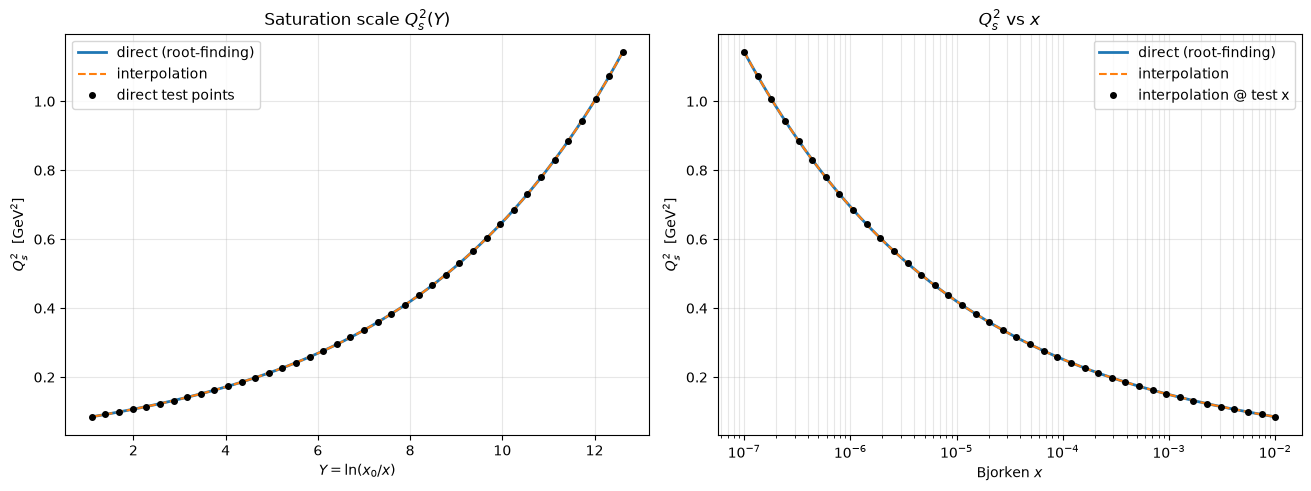

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8), constrained_layout=True)

axes[0].plot(Y_range, Qs2, lw=2, label='direct (root-finding)')
axes[0].plot(Y_range, Qs2_from_interp, '--', lw=1.5, label='interpolation')
axes[0].plot(np.log(3e-2 / x_test), Qs2_test_direct, 'o', ms=4,
             color='k', label='direct test points')
axes[0].set_xlabel(r'$Y = \ln(x_0/x)$')
axes[0].set_ylabel(r'$Q_s^2$  [GeV$^2$]')
axes[0].set_title(r'Saturation scale $Q_s^2(Y)$')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(x_range, Qs2, lw=2, label='direct (root-finding)')
axes[1].plot(x_range, Qs2_from_interp, '--', lw=1.5, label='interpolation')
axes[1].plot(x_test, Qs2_test_interp, 'o', ms=4, color='k', label='interpolation @ test x')
axes[1].set_xscale('log')
# axes[1].set_yscale('log')
axes[1].set_xlabel(r'Bjorken $x$')
axes[1].set_ylabel(r'$Q_s^2$  [GeV$^2$]')
axes[1].set_title(r'$Q_s^2$ vs $x$')
axes[1].legend()
axes[1].grid(alpha=0.3, which='both')
plt.show()

## 8. One-loop running coupling $\alpha_s(\mu^2)$

The one-loop QCD running coupling is

$$\alpha_s(\mu^2)=\frac{4\pi}{\beta_0\,\ln\!\left(\mu^2/\Lambda_{\rm QCD}^2\right)},\qquad
\beta_0=11-\frac{2 n_f}{3}.$$

To avoid the Landau pole at $\mu^2\to\Lambda_{\rm QCD}^2$, the coupling is **frozen** in the infrared: below the scale where the perturbative value reaches $\alpha_{\max}$,

$$\mu^2_{\rm fr}=\Lambda_{\rm QCD}^2\,\exp\!\left(\frac{4\pi}{\beta_0\,\alpha_{\max}}\right),$$

we set $\alpha_s(\mu^2)=\alpha_s\!\big(\max(\mu^2,\mu^2_{\rm fr})\big)$, so $\alpha_s\le\alpha_{\max}$ everywhere.

Below we evaluate it at the saturation scale, $\mu^2=Q_s^2(Y)$, using the interpolated table from Section 7, and plot $\alpha_s(Q_s^2)$ versus $Y$.

alpha_s(Q_s^2) range: [0.4165, 0.7000]


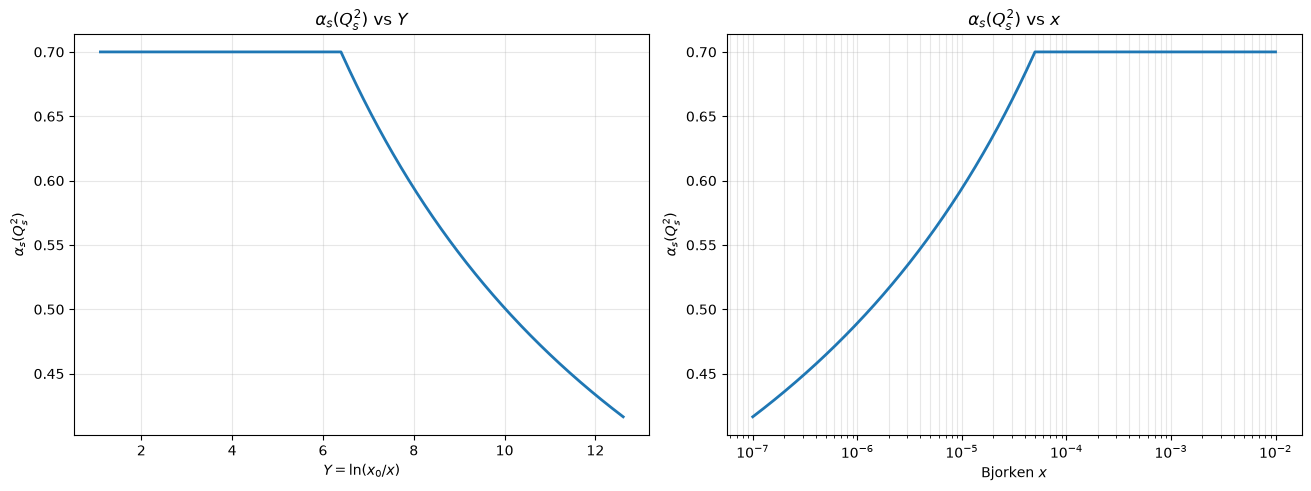

In [13]:
###runing_alpha_s
# One-loop running coupling with infrared (Landau-pole) freezing.
#   alpha_s(mu2) = 4*pi / [ beta0 * ln(mu2 / Lambda_QCD^2) ],   beta0 = 11 - 2*n_f/3
# Below the scale where the perturbative value would exceed alpha_max, the
# coupling is frozen to alpha_max (avoids the Landau pole and fixes the IR).

def alpha_s_1loop(mu2, Lambda_QCD=0.2, n_f=3, alpha_max=0.7):
    """One-loop running alpha_s(mu2). mu2 is the squared scale in GeV^2."""
    mu2 = np.asarray(mu2, dtype=float)
    beta0 = 11.0 - 2.0 * n_f / 3.0
    Lambda2 = Lambda_QCD ** 2
    freeze_mu2 = Lambda2 * np.exp(4.0 * np.pi / (beta0 * alpha_max))
    mu2_eff = np.maximum(mu2, freeze_mu2)
    return 4.0 * np.pi / (beta0 * np.log(mu2_eff / Lambda2))


# Quick demo: evaluate at mu^2 = Q_s^2(Y) using the interpolated table above.
alpha_at_Qs2 = alpha_s_1loop(Qs2_from_interp)
print(f'alpha_s(Q_s^2) range: [{alpha_at_Qs2.min():.4f}, {alpha_at_Qs2.max():.4f}]')

fig, axes = plt.subplots(1, 2, figsize=(13, 4.8), constrained_layout=True)

axes[0].plot(Y_range, alpha_at_Qs2, lw=2)
axes[0].set_xlabel(r'$Y = \ln(x_0/x)$')
axes[0].set_ylabel(r'$\alpha_s(Q_s^2)$')
axes[0].set_title(r'$\alpha_s(Q_s^2)$ vs $Y$')
axes[0].grid(alpha=0.3)

axes[1].plot(x_range, alpha_at_Qs2, lw=2)
axes[1].set_xscale('log')
axes[1].set_xlabel(r'Bjorken $x$')
axes[1].set_ylabel(r'$\alpha_s(Q_s^2)$')
axes[1].set_title(r'$\alpha_s(Q_s^2)$ vs $x$')
axes[1].grid(alpha=0.3, which='both')

plt.show()

## 9. WW input $\widetilde{q}(x,r;Q_0^2)$ vs $r$ for different $x$

The coordinate-space WW input at the initial scale is

$$\widetilde{q}(x,r;Q_0^2)=\mathcal{F}_{WW}\big(r,Q_0(x)\big)
=\frac{1}{\alpha_s(Q_0^2)}\,\frac{C_F S_\perp}{2\pi^2}\,
\mathcal{K}(r,x)\left[1-\big(S_F(r,x)\big)^{N_c/C_F}\right],$$

where the initial scale is the saturation scale, $Q_0=Q_s(x)$, obtained in Section 7. The bracketed factor $\tfrac{C_F S_\perp}{2\pi^2}\mathcal{K}[1-S_F^{N_c/C_F}]$ is exactly `ww_alpha_s_f_r_autograd` (i.e. $\alpha_s F_{WW}$), so

$$\widetilde{q}(x,r)=\frac{\texttt{ww\_alpha\_s\_f\_r\_autograd}(r,x)}{\alpha_s\!\big(Q_s^2(x)\big)}.$$

We use the float64 autograd evaluation (Section 6) to keep the small-$r$ region clean, and overlay several $x$ values in a single figure.

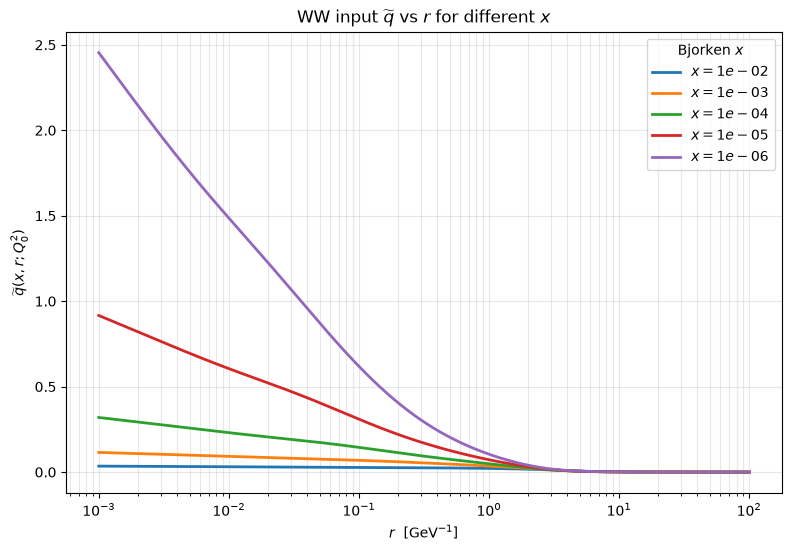

In [14]:
# q_tilde(x, r) = [alpha_s F_WW](r, x) / alpha_s(Q_s^2(x)),  Q_0 = Q_s(x)
r_q = np.geomspace(1.0e-3, 1.0e2, 500)      # r grid [GeV^-1]
x_values = [1.0e-2, 1.0e-3, 1.0e-4, 1.0e-5, 1.0e-6]

fig, ax = plt.subplots(figsize=(7.8, 5.4), constrained_layout=True)

for xv in x_values:
    Qs2_x = float(Qs2_interp(xv))              # Q_s^2(x) from Section 7 table
    alpha_Q0 = float(alpha_s_1loop(Qs2_x))     # alpha_s(Q_0^2)
    aFww = ww_alpha_s_f_r_autograd(
        r_q, xv, S_perp=S_PERP, Nc=NC, x0_for_Y=X0_FOR_Y, eps=EPS, dtype=torch.float64
    )
    q_tilde = aFww / alpha_Q0
    ax.plot(r_q, q_tilde, lw=2, label=fr'$x={xv:.0e}$')

ax.set_xscale('log')
ax.set_xscale('log')
ax.set_xlabel(r'$r$  [GeV$^{-1}$]')
ax.set_ylabel(r'$\widetilde{q}(x,r;Q_0^2)$')
ax.set_title(r'WW input $\widetilde{q}$ vs $r$ for different $x$')
ax.legend(title=r'Bjorken $x$')
ax.grid(alpha=0.3, which='both')
plt.show()

## 10. Sudakov-evolved momentum-space WW distribution

We now evaluate the requested three-scale Weizsäcker-Williams distribution

$$
{\cal F}_{WW}(x,k;Q^2)
=\frac{1}{2\pi}\int_0^\infty dr\,r\,J_0(kr)
\exp[-S_g^{\rm run}(Q,r)]\,\widetilde q(x,r),
$$

with

$$
\widetilde q(x,r)=\frac{1}{\alpha_s(Q_s^2(x))}
\frac{C_FS_\perp}{2\pi^2}
\frac{\nabla_r^2[-\log S_F(r,x)]}{-\log S_F(r,x)}
\left[1-S_F(r,x)^{C_A/C_F}\right],
$$

and

$$
S_g^{\rm run}(Q,r)=\frac{C_A}{2\pi}
\int_{Q_s^2(x)}^{Q^2}\frac{d\mu^2}{\mu^2}\,
\alpha_s(\mu^2)\log\frac{Q^2}{\mu^2}
+g_2r^2\log\frac{Q^2}{Q_s^2(x)},
\qquad g_2=0.225.
$$

The phrase “Gauss-Lagrange” is interpreted here as **Gauss-Legendre
quadrature**, the standard Gaussian rule. The finite Sudakov integral and every
radial panel use that rule. The oscillatory radial panels are additionally
aligned with the $J_0(kr)$ oscillation scale.

In [15]:
from dataclasses import replace
from pathlib import Path
import hashlib
import shutil
import sys
import time

import matplotlib.pyplot as plt
import numpy as np
import torch

PROJECT_ROOT = Path('/home/congyi/work/dipole_function')
DIS_SRC = PROJECT_ROOT / 'DIS' / 'src'
if str(DIS_SRC) not in sys.path:
    sys.path.insert(0, str(DIS_SRC))

from fww_table_generator import (
    FWWTableConfig,
    build_table_grids,
    evaluate_x_slice,
    generate_table,
    interpolate_qs2,
    load_qs2_table,
    read_binary_table,
    sudakov_perturbative_gauss_legendre,
)

FWW_CONFIG = FWWTableConfig(g2=0.225)
TABLE_DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print('table device:', TABLE_DEVICE)
if TABLE_DEVICE.type == 'cuda':
    print('GPU:', torch.cuda.get_device_name(TABLE_DEVICE))
print('g2 =', FWW_CONFIG.g2)
print('radial Gauss-Legendre order =', FWW_CONFIG.radial_gauss_order)

Running on the GPU
table device: cuda
GPU: NVIDIA GeForce RTX 5080
g2 = 0.225
radial Gauss-Legendre order = 16


### 10.1 Logarithmic production grids

The $x$ and $k$ axes are common logarithmic grids with 100 points each. At
each $x_i$, the 200-point $Q^2$ axis starts exactly at the local saturation
scale and ends at $400\;{\rm GeV}^2$:

$$
x_i=10^{-7}\left(\frac{10^{-2}}{10^{-7}}\right)^{i/99},\qquad
k_j=10^{-3}\left(\frac{100}{10^{-3}}\right)^{j/99},
$$

$$
Q^2_{i\ell}=Q_s^2(x_i)
\left(\frac{400}{Q_s^2(x_i)}\right)^{\ell/199}.
$$

The normalized coordinate $\eta_\ell=\ell/199$ makes the variable lower
boundary compatible with regular three-dimensional interpolation.

In [16]:
QS2_SOURCE = DIS_SRC / 'Qs2_table.dat'
qs2_table_x, qs2_table_values = load_qs2_table(QS2_SOURCE)
x_fww, k_fww, qs2_fww, eta_fww, q2_fww = build_table_grids(
    FWW_CONFIG, qs2_table_x, qs2_table_values
)

print('grid shape:', (len(x_fww), len(k_fww), len(eta_fww)))
print('x range:', x_fww[[0, -1]])
print('k range [GeV]:', k_fww[[0, -1]])
print('Qs2 range [GeV^2]:', [qs2_fww.min(), qs2_fww.max()])
print('first Q2 row endpoints:', q2_fww[0, [0, -1]])
print('last Q2 row endpoints:', q2_fww[-1, [0, -1]])

grid shape: (100, 100, 200)
x range: [1.e-07 1.e-02]
k range [GeV]: [1.e-03 1.e+02]
Qs2 range [GeV^2]: [np.float64(0.084875952046), np.float64(1.1431572667)]
first Q2 row endpoints: [  1.14315727 400.        ]
last Q2 row endpoints: [8.4875952e-02 4.0000000e+02]


### 10.2 Running-coupling Sudakov integral

Changing variables to $t=\log\mu^2$ converts the perturbative term to a finite
smooth integral,

$$
S_{g,\rm pert}^{\rm run}(x,Q^2)=\frac{C_A}{2\pi}
\int_{\log Q_s^2(x)}^{\log Q^2}dt\,
\alpha_s(e^t)\,[\log Q^2-t].
$$

It is evaluated with a 64-point Gauss-Legendre rule. The following comparison
against 128 points verifies that this order is already converged.

In [17]:
qs2_check = float(qs2_fww[len(qs2_fww) // 2])
q2_check = np.geomspace(qs2_check, FWW_CONFIG.q2_max, 200)
sudakov_64 = sudakov_perturbative_gauss_legendre(
    qs2_check, q2_check, FWW_CONFIG, order=64
)
sudakov_128 = sudakov_perturbative_gauss_legendre(
    qs2_check, q2_check, FWW_CONFIG, order=128
)

print('Sudakov max absolute difference, 64 vs 128 =',
      np.max(np.abs(sudakov_64 - sudakov_128)))

Sudakov max absolute difference, 64 vs 128 = 7.460698725481052e-14


### 10.3 Composite Gauss-Legendre rule for the Hankel integral

A single global polynomial rule cannot reliably resolve all oscillations up to
$k=100\;{\rm GeV}$. We therefore partition the radial domain using the union
of logarithmic edges and edges separated by $\pi/k$. On every panel
$[r_a,r_b]$ we apply a 16-point Gauss-Legendre rule,

$$
\int_{r_a}^{r_b}dr\,f(r)
\simeq \frac{r_b-r_a}{2}\sum_{n=1}^{16}w_n
f\!\left(\frac{r_a+r_b}{2}+\frac{r_b-r_a}{2}z_n\right).
$$

The PINN WW profile is zero to numerical precision beyond
$r=3000\;{\rm GeV}^{-1}$, which is used as the effective upper limit. For
$Q^2>Q_s^2$, the Gaussian factor
$\exp[-g_2r^2\log(Q^2/Q_s^2)]$ permits a smaller, explicitly tolerance-controlled
limit. The next cell checks the production rule against a denser rule.

In [18]:
x_check = float(x_fww[-1])
qs2_check = float(qs2_fww[-1])
k_check = np.array([1.0e-3, 1.0e-1, 1.0, 10.0, 100.0])
q2_check = np.geomspace(qs2_check, FWW_CONFIG.q2_max, 9)

production_check = evaluate_x_slice(
    x_check, qs2_check, k_check, q2_check, FWW_CONFIG, device=TABLE_DEVICE
)
dense_config = replace(
    FWW_CONFIG,
    radial_gauss_order=20,
    radial_log_step=0.04,
    profile_points=65536,
)
dense_check = evaluate_x_slice(
    x_check, qs2_check, k_check, q2_check, dense_config, device=TABLE_DEVICE
)
quadrature_relative = np.abs(production_check - dense_check) / np.maximum(
    np.abs(dense_check), 1.0e-14
)

print('radial convergence max relative difference =',
      np.max(quadrature_relative))
print('radial convergence 99th percentile =',
      np.quantile(quadrature_relative, 0.99))

radial convergence max relative difference = 1.1602903976977924e-05
radial convergence 99th percentile = 8.364573297790025e-06


### 10.4 Full $100\times100\times200$ table generation

For each $x_i$, the code first computes $\widetilde q(x_i,r)$ with float64
automatic differentiation. It then evaluates

$$
{\cal F}_{WW}(x_i,k_j;Q^2_{i\ell})
=\frac{e^{-S_{g,\rm pert}^{\rm run}(x_i,Q^2_{i\ell})}}{2\pi}
\int_0^\infty dr\,rJ_0(k_jr)
e^{-g_2r^2\log(Q^2_{i\ell}/Q_s^2(x_i))}\widetilde q(x_i,r).
$$

Generation is checkpointed after every $x$ slice. The compact binary table
stores the four axes $(x,k,Q_s^2,\eta)$ followed by the float64 values in
$(x,k,\eta)$ order. A master copy is written beside this notebook and then
copied byte-for-byte to `DIS/src/FWW_TMD_TABLE.bin`.

In [19]:
TABLE_WORK = PROJECT_ROOT / 'fww_table_work'
TABLE_MASTER = PROJECT_ROOT / 'FWW_TMD_TABLE.bin'
TABLE_DIS = DIS_SRC / 'FWW_TMD_TABLE.bin'

generation_start = time.perf_counter()
generate_table(
    FWW_CONFIG,
    qs2_table_path=QS2_SOURCE,
    work_directory=TABLE_WORK,
    output_path=TABLE_MASTER,
    device=TABLE_DEVICE,
)
shutil.copy2(TABLE_MASTER, TABLE_DIS)

print('generation/copy elapsed [s]:', time.perf_counter() - generation_start)
print('master table:', TABLE_MASTER)
print('DIS table:', TABLE_DIS)

[  1/100] x=1.000000e-07: checkpoint already complete
[  2/100] x=1.123324e-07: checkpoint already complete
[  3/100] x=1.261857e-07: checkpoint already complete
[  4/100] x=1.417474e-07: checkpoint already complete
[  5/100] x=1.592283e-07: checkpoint already complete
[  6/100] x=1.788650e-07: checkpoint already complete
[  7/100] x=2.009233e-07: checkpoint already complete
[  8/100] x=2.257020e-07: checkpoint already complete
[  9/100] x=2.535364e-07: checkpoint already complete
[ 10/100] x=2.848036e-07: checkpoint already complete
[ 11/100] x=3.199267e-07: checkpoint already complete
[ 12/100] x=3.593814e-07: checkpoint already complete
[ 13/100] x=4.037017e-07: checkpoint already complete
[ 14/100] x=4.534879e-07: checkpoint already complete
[ 15/100] x=5.094138e-07: checkpoint already complete
[ 16/100] x=5.722368e-07: checkpoint already complete
[ 17/100] x=6.428073e-07: checkpoint already complete
[ 18/100] x=7.220809e-07: checkpoint already complete
[ 19/100] x=8.111308e-07: ch

### 10.5 Binary-table integrity checks

The table must contain exactly $100\times100\times200=2{,}000{,}000$ finite
values, preserve $g_2=0.225$, and have identical master and DIS copies. We also
check positivity rather than silently clipping the transform.

In [20]:
table_meta, table_x, table_k, table_qs2, table_eta, table_fww = read_binary_table(
    TABLE_DIS
)

def sha256(path):
    digest = hashlib.sha256()
    with Path(path).open('rb') as stream:
        for chunk in iter(lambda: stream.read(1024 * 1024), b''):
            digest.update(chunk)
    return digest.hexdigest()

print('metadata:', table_meta)
print('value shape:', table_fww.shape)
print('finite values:', np.isfinite(table_fww).sum(), '/', table_fww.size)
print('value range:', [table_fww.min(), table_fww.max()])
print('negative-value count:', np.count_nonzero(table_fww < 0.0))
print('master SHA-256:', sha256(TABLE_MASTER))
print('DIS SHA-256:   ', sha256(TABLE_DIS))
assert sha256(TABLE_MASTER) == sha256(TABLE_DIS)

metadata: {'n_x': 100, 'n_k': 100, 'n_q2': 200, 'q2_max': 400.0, 'g2': 0.225}
value shape: (100, 100, 200)
finite values: 2000000 / 2000000
value range: [np.float64(1.445739824224163e-11), np.float64(0.09024719158935089)]
negative-value count: 0
master SHA-256: 970333b8a228dfd8d4cfde51571e744a1244d2ad9b22022c8bf2b018d8b3196d
DIS SHA-256:    970333b8a228dfd8d4cfde51571e744a1244d2ad9b22022c8bf2b018d8b3196d


### 10.6 Final $\mathcal F_{WW}(x,k;Q^2)$ curves

The table is plotted as a function of $k$ at four representative $x$ values.
For each panel, four logarithmically separated scale nodes are shown, including
$Q^2=Q_s^2(x)$ and $Q^2=400\;{\rm GeV}^2$.

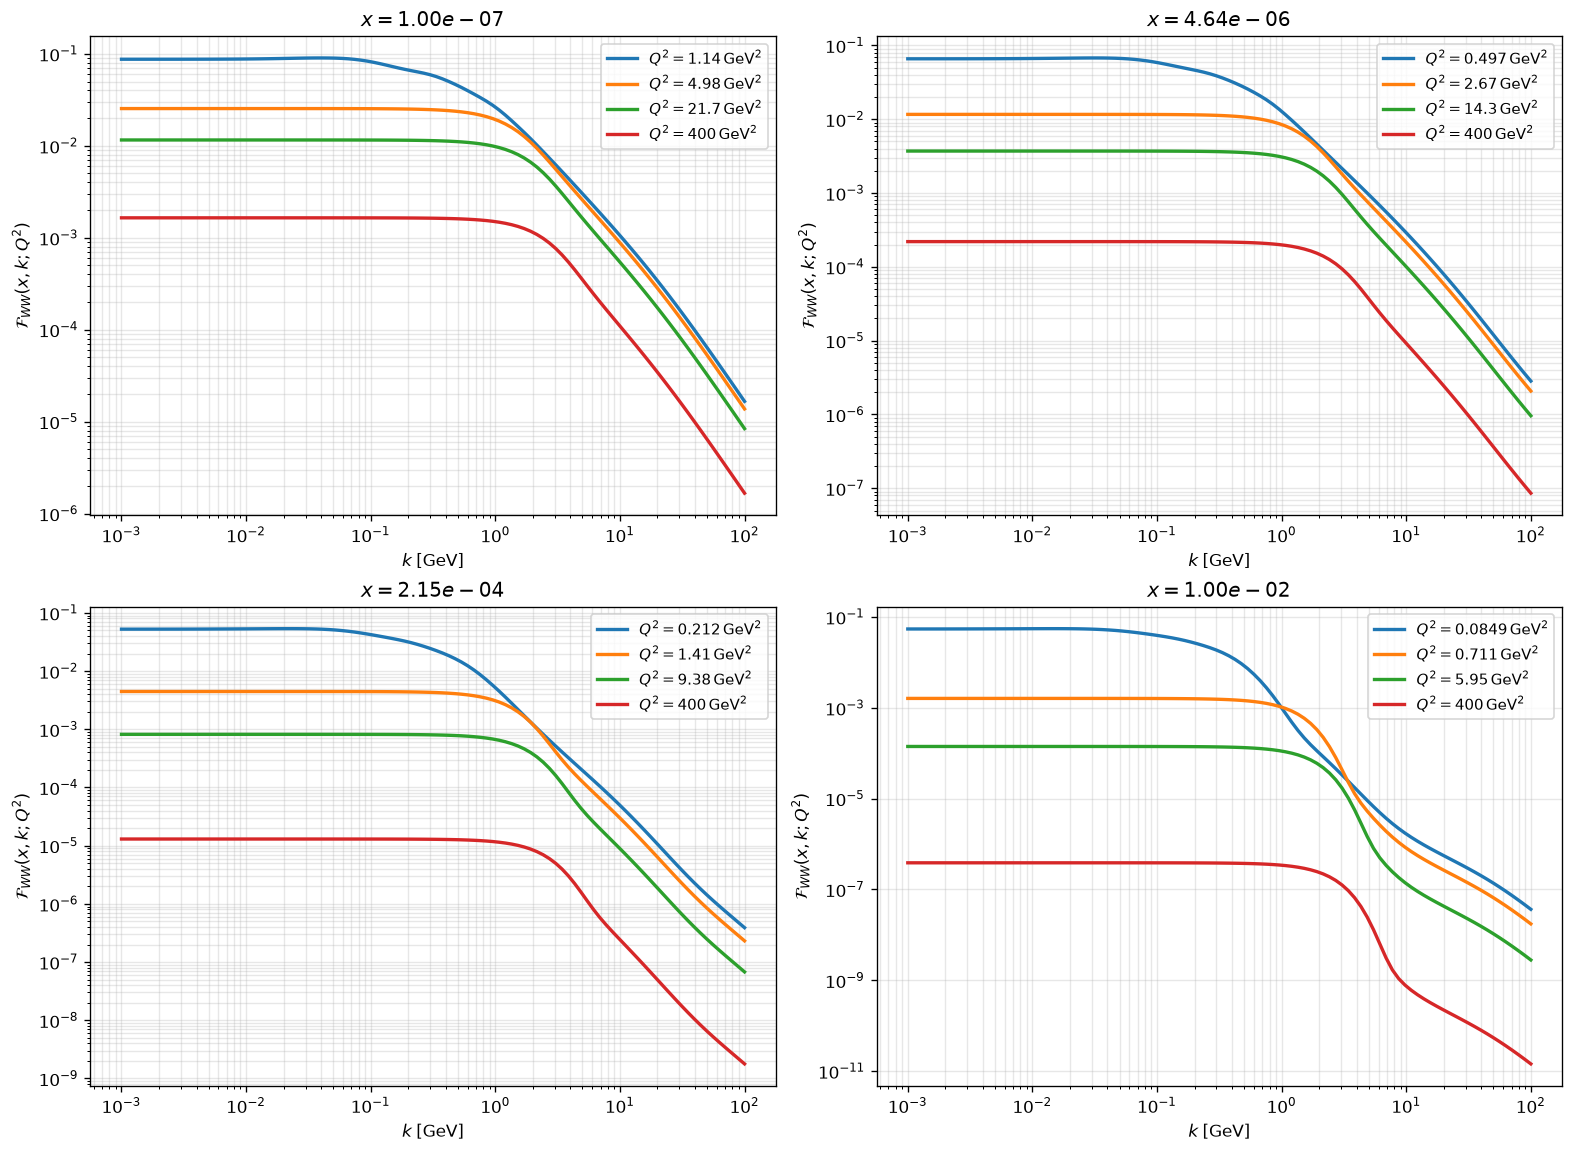

In [ ]:
x_indices = [0, len(table_x) // 3, 2 * len(table_x) // 3, len(table_x) - 1]
q_indices = [0, len(table_eta) // 4, len(table_eta) // 2, len(table_eta) - 1]

fig, axes = plt.subplots(2, 2, figsize=(13, 9.5), constrained_layout=True)
for ax, ix in zip(axes.flat, x_indices):
    for iq in q_indices:
        q2_value = table_qs2[ix] * (
            table_meta['q2_max'] / table_qs2[ix]
        ) ** table_eta[iq]
        ax.plot(
            table_k,
            table_fww[ix, :, iq],
            lw=2,
            label=fr'$Q^2={q2_value:.3g}\,\mathrm{{GeV}}^2$',
        )
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_xlabel(r'$k\;[\mathrm{GeV}]$')
    ax.set_ylabel(r'$\mathcal{F}_{WW}(x,k;Q^2)$')
    ax.set_title(fr'$x={table_x[ix]:.2e}$')
    ax.grid(alpha=0.3, which='both')
    ax.legend(fontsize=9)``

plt.show()

### 10.7 Reference three-dimensional interpolation

The DIS implementation uses the same transformed scale coordinate

$$
\eta(x,Q^2)=\frac{\log[Q^2/Q_s^2(x)]}
{\log[400/Q_s^2(x)]}
$$

and trilinearly interpolates in $(\log x,\log k,\eta)$. The reference function
below mirrors the C++ implementation. It returns exactly $-1$ whenever
$x$, $k$, or $Q^2$ is outside the tabulated physical domain.

In [22]:
def interpolate_fww_3d(x, k, q2):
    if (
        not np.isfinite(x) or not np.isfinite(k) or not np.isfinite(q2)
        or x < table_x[0] or x > table_x[-1]
        or k < table_k[0] or k > table_k[-1]
        or q2 <= 0.0
    ):
        return -1.0

    log_x = np.log(x)
    log_k = np.log(k)
    log_x_axis = np.log(table_x)
    log_k_axis = np.log(table_k)
    qs2 = np.interp(log_x, log_x_axis, table_qs2)
    tolerance = 64.0 * np.finfo(float).eps * max(1.0, abs(qs2), abs(q2))
    if q2 < qs2 - tolerance or q2 > table_meta['q2_max'] + tolerance:
        return -1.0

    q2 = np.clip(q2, qs2, table_meta['q2_max'])
    eta = np.log(q2 / qs2) / np.log(table_meta['q2_max'] / qs2)

    def cell(axis, value):
        index = int(np.searchsorted(axis, value, side='right') - 1)
        index = min(max(index, 0), len(axis) - 2)
        weight = (value - axis[index]) / (axis[index + 1] - axis[index])
        return index, weight

    ix, tx = cell(log_x_axis, log_x)
    ik, tk = cell(log_k_axis, log_k)
    iq, tq = cell(table_eta, eta)

    cube = table_fww[ix:ix + 2, ik:ik + 2, iq:iq + 2]
    along_q = cube[:, :, 0] + tq * (cube[:, :, 1] - cube[:, :, 0])
    along_k = along_q[:, 0] + tk * (along_q[:, 1] - along_q[:, 0])
    return float(along_k[0] + tx * (along_k[1] - along_k[0]))

ix, ik, iq = 23, 47, 91
q2_node = table_qs2[ix] * (
    table_meta['q2_max'] / table_qs2[ix]
) ** table_eta[iq]
node_value = interpolate_fww_3d(table_x[ix], table_k[ik], q2_node)

print('exact-node interpolation difference =',
      abs(node_value - table_fww[ix, ik, iq]))
print('outside x ->', interpolate_fww_3d(0.5 * table_x[0], table_k[0], table_qs2[0]))
print('outside k ->', interpolate_fww_3d(table_x[0], 2.0 * table_k[-1], table_qs2[0]))
print('below Qs2 ->', interpolate_fww_3d(table_x[0], table_k[0], 0.9 * table_qs2[0]))
print('above Q2 max ->', interpolate_fww_3d(table_x[0], table_k[0], 401.0))

exact-node interpolation difference = 1.734723475976807e-18
outside x -> -1.0
outside k -> -1.0
below Qs2 -> -1.0
above Q2 max -> -1.0
